# CRM Analytics Dashboard

**Portfolio dashboard** built from `CRM_Cleaned.csv`  
**Stack:** Matplotlib (KPI strip) · Seaborn (distributions / comparisons) · Plotly (interactive views)

### See everything in one place
Open the single-page HTML dashboard (all KPIs + charts together):

**[`CRM_Dashboard.html`](CRM_Dashboard.html)**

Regenerate anytime with: `python build_crm_dashboard_html.py`

### Notebook map (section-by-section)
1. Executive KPI strip
2. Lead funnel (interactive)
3. Revenue & growth
4. Marketing source performance
5. Sales rep leaderboard
6. Segment & industry
7. Satisfaction & response time
8. Insight summary

In [1]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

COLOR = {
    "navy": "#013a63",
    "blue": "#01497c",
    "teal": "#2a6f97",
    "mid": "#468faf",
    "soft": "#89c2d9",
    "light": "#a9d6e5",
    "ink": "#212529",
    "muted": "#6c757d",
}

PLOTLY_TEMPLATE = "plotly_white"

## Data

In [2]:
df = pd.read_csv(
    "CRM_Cleaned.csv",
    parse_dates=["Signup_Date", "Last_Contact_Date"],
)

for col in ["Is_Won", "Has_Revenue"]:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.lower().isin(["true", "1", "yes"])

df["Signup_Month"] = df["Signup_Date"].dt.to_period("M").dt.to_timestamp()
df["Revenue_Filled"] = df["Revenue"].fillna(0)

total_customers = len(df)
won = int(df["Is_Won"].sum())
lost = int((df["Lead_Stage"] == "Lost").sum())
conversion = won / total_customers
total_revenue = df["Revenue_Filled"].sum()
avg_won_revenue = df.loc[df["Is_Won"], "Revenue"].mean()
avg_csat = df["Customer_Satisfaction"].mean()
avg_response = df["Response_Time_Hours"].mean()
avg_lead_score = df["Lead_Score"].mean()

print(f"Loaded {total_customers:,} customers | Won {won:,} | Revenue ${total_revenue:,.0f}")

Loaded 5,000 customers | Won 819 | Revenue $1,643,197


## 1) Executive KPI strip (Matplotlib)

One composition for the first view: six headline metrics only.

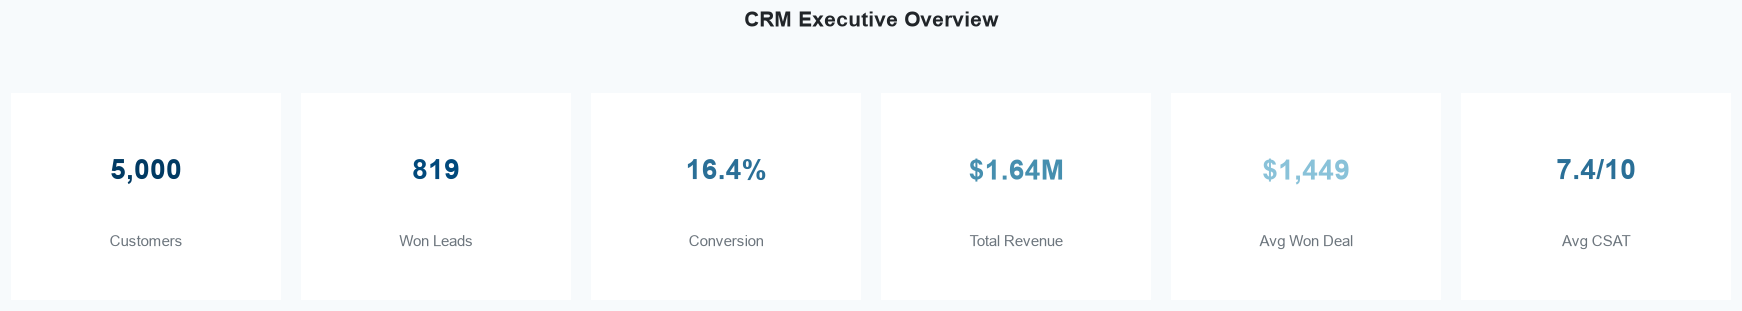

In [3]:
kpis = [
    ("Customers", f"{total_customers:,}"),
    ("Won Leads", f"{won:,}"),
    ("Conversion", f"{conversion:.1%}"),
    ("Total Revenue", f"${total_revenue/1e6:.2f}M"),
    ("Avg Won Deal", f"${avg_won_revenue:,.0f}"),
    ("Avg CSAT", f"{avg_csat:.1f}/10"),
]

fig, axes = plt.subplots(1, 6, figsize=(16, 2.6))
fig.patch.set_facecolor("#f7fafc")

for ax, (label, value), tone in zip(axes, kpis, [COLOR["navy"], COLOR["blue"], COLOR["teal"], COLOR["mid"], COLOR["soft"], COLOR["teal"]]):
    ax.set_facecolor("#ffffff")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=18, fontweight="bold", color=tone)
    ax.text(0.5, 0.28, label, ha="center", va="center", fontsize=10, color=COLOR["muted"])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

fig.suptitle("CRM Executive Overview", fontsize=14, fontweight="bold", color=COLOR["ink"], y=1.08)
plt.tight_layout()
plt.show()

## 2) Lead funnel (Plotly — interactive)

In [4]:
funnel_order = ["New Lead", "Contacted", "Qualified", "Proposal", "Negotiation", "Won"]
stage_counts = df["Lead_Stage"].value_counts()
funnel_df = pd.DataFrame({
    "Stage": funnel_order,
    "Count": [int(stage_counts.get(s, 0)) for s in funnel_order],
})

fig = go.Figure(go.Funnel(
    y=funnel_df["Stage"],
    x=funnel_df["Count"],
    textinfo="value+percent initial",
    marker={"color": [COLOR["light"], COLOR["soft"], COLOR["mid"], COLOR["teal"], COLOR["blue"], COLOR["navy"]]},
))
fig.update_layout(
    title="Lead Funnel (current stage snapshot)",
    template=PLOTLY_TEMPLATE,
    height=420,
    margin=dict(l=40, r=40, t=60, b=40),
)
fig.show()

print(f"Lost (exit stage): {lost:,} | Overall conversion: {conversion:.1%}")

Lost (exit stage): 433 | Overall conversion: 16.4%


## 3) Revenue & growth (Plotly)

In [5]:
monthly = (
    df.groupby("Signup_Month", as_index=False)
    .agg(signups=("Customer_ID", "count"), won=("Is_Won", "sum"))
)
won_monthly = (
    df.loc[df["Is_Won"]]
    .groupby("Signup_Month", as_index=False)["Revenue"]
    .sum()
    .rename(columns={"Revenue": "won_revenue"})
)
monthly = monthly.merge(won_monthly, on="Signup_Month", how="left")
monthly["won_revenue"] = monthly["won_revenue"].fillna(0)
monthly["won_revenue_ma3"] = monthly["won_revenue"].rolling(3, min_periods=1).mean()

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Bar(x=monthly["Signup_Month"], y=monthly["won_revenue"], name="Won Revenue", marker_color=COLOR["soft"]),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=monthly["Signup_Month"], y=monthly["won_revenue_ma3"], name="3-mo Avg Revenue", line=dict(color=COLOR["navy"], width=3)),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=monthly["Signup_Month"], y=monthly["signups"], name="Signups", line=dict(color=COLOR["teal"], width=2, dash="dot")),
    secondary_y=True,
)
fig.update_layout(
    title="Won Revenue & Signups by Signup Month",
    template=PLOTLY_TEMPLATE,
    height=420,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    margin=dict(l=40, r=40, t=80, b=40),
)
fig.update_yaxes(title_text="Won Revenue ($)", secondary_y=False)
fig.update_yaxes(title_text="Signups", secondary_y=True)
fig.show()

## 4) Marketing source performance (Plotly + Seaborn)

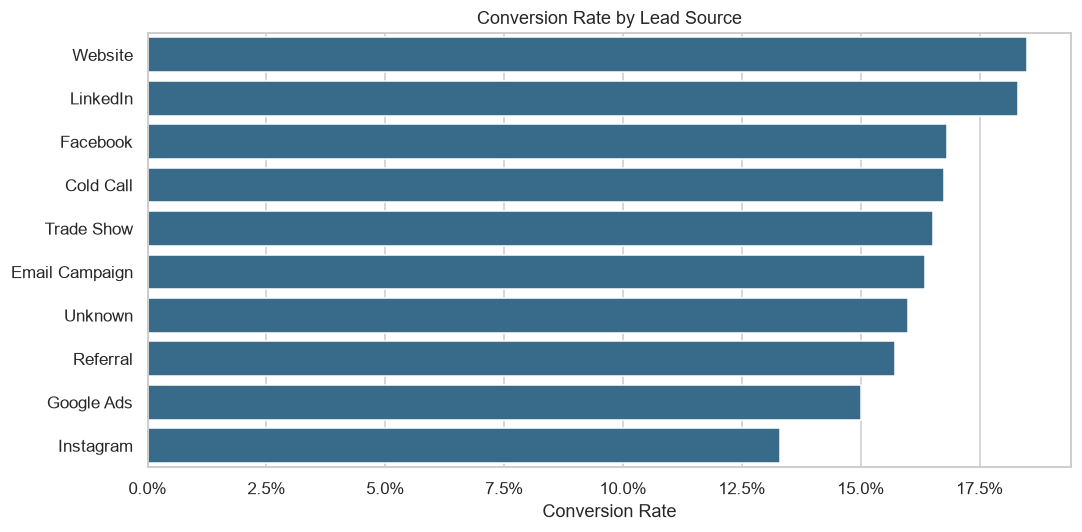

In [6]:
source = (
    df.groupby("Lead_Source", as_index=False)
    .agg(
        leads=("Customer_ID", "count"),
        won=("Is_Won", "sum"),
        revenue=("Revenue_Filled", "sum"),
        avg_csat=("Customer_Satisfaction", "mean"),
    )
)
source["conversion_rate"] = source["won"] / source["leads"]
source = source.sort_values("revenue", ascending=False)

fig = px.scatter(
    source,
    x="conversion_rate",
    y="revenue",
    size="leads",
    color="Lead_Source",
    hover_data={"leads": True, "won": True, "avg_csat": ":.2f", "conversion_rate": ":.1%", "revenue": ":,.0f"},
    title="Lead Sources: Conversion vs Revenue (bubble = lead volume)",
    template=PLOTLY_TEMPLATE,
    color_discrete_sequence=px.colors.sequential.Blues[2:],
)
fig.update_layout(height=480, xaxis_tickformat=".0%")
fig.show()

fig2, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=source.sort_values("conversion_rate", ascending=False),
    x="conversion_rate",
    y="Lead_Source",
    ax=ax,
    color=COLOR["teal"],
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Conversion Rate by Lead Source")
ax.set_xlabel("Conversion Rate")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5) Sales rep leaderboard (Plotly)

In [7]:
rep = (
    df.groupby("Assigned_Sales_Rep", as_index=False)
    .agg(
        leads=("Customer_ID", "count"),
        won=("Is_Won", "sum"),
        revenue=("Revenue_Filled", "sum"),
        avg_csat=("Customer_Satisfaction", "mean"),
        avg_response=("Response_Time_Hours", "mean"),
    )
)
rep["conversion_rate"] = rep["won"] / rep["leads"]
rep = rep.sort_values("revenue", ascending=True)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Revenue by Sales Rep", "Conversion Rate by Sales Rep"),
    horizontal_spacing=0.12,
)
fig.add_trace(
    go.Bar(x=rep["revenue"], y=rep["Assigned_Sales_Rep"], orientation="h", marker_color=COLOR["blue"], name="Revenue",
           hovertemplate="%{y}<br>Revenue: $%{x:,.0f}<extra></extra>"),
    row=1, col=1,
)
fig.add_trace(
    go.Bar(x=rep["conversion_rate"], y=rep["Assigned_Sales_Rep"], orientation="h", marker_color=COLOR["teal"], name="Conversion",
           hovertemplate="%{y}<br>Conversion: %{x:.1%}<extra></extra>"),
    row=1, col=2,
)
fig.update_layout(
    title="Sales Representative Performance",
    template=PLOTLY_TEMPLATE,
    height=420,
    showlegend=False,
    margin=dict(l=40, r=40, t=80, b=40),
)
fig.update_xaxes(tickformat=".0%", row=1, col=2)
fig.show()

rep.sort_values("revenue", ascending=False).round({"avg_csat": 2, "avg_response": 1, "conversion_rate": 3})

,Assigned_Sales_Rep,leads,won,revenue,avg_csat,avg_response,conversion_rate
4,Samer Khalil,848,144,329110.48,7.36,11.0,0.170
5,Yara Odeh,850,121,319138.01,7.31,11.2,0.142
3,Omar Mansour,811,141,270459.56,7.47,11.1,0.174
2,Lina Haddad,808,134,259539.06,7.39,11.3,0.166
0,Ahmad Saleh,816,152,258593.30,7.31,11.0,0.186
1,Dana Nasser,867,127,206356.16,7.38,11.5,0.146


## 6) Segment & industry (Seaborn + Plotly)

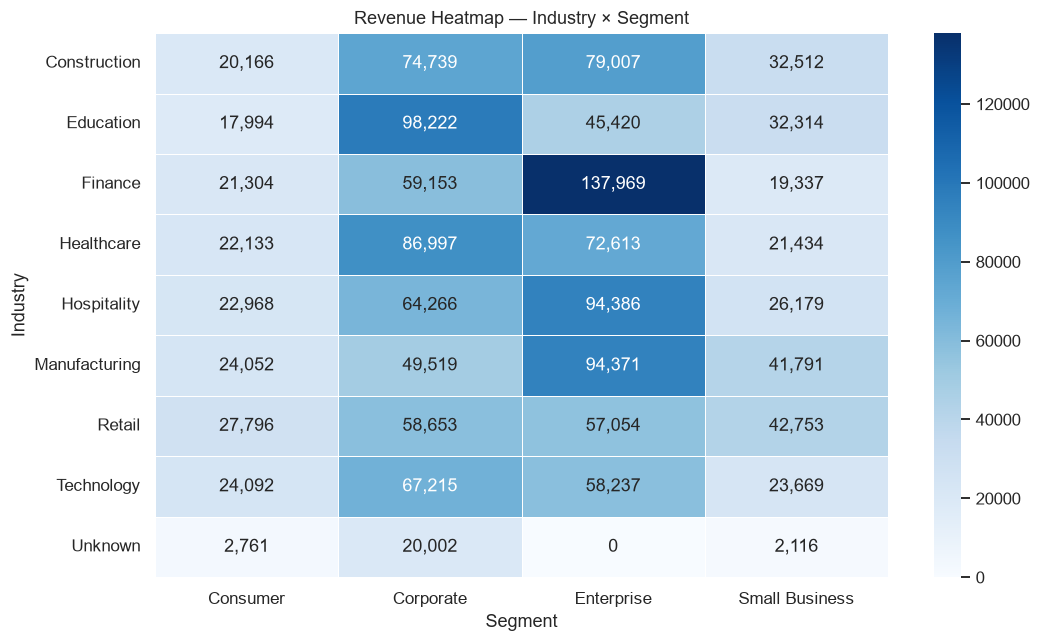

In [8]:
seg = (
    df.groupby(["Customer_Segment", "Industry"], as_index=False)
    .agg(revenue=("Revenue_Filled", "sum"), leads=("Customer_ID", "count"), won=("Is_Won", "sum"))
)
seg["conversion_rate"] = seg["won"] / seg["leads"]

pivot_rev = seg.pivot_table(index="Industry", columns="Customer_Segment", values="revenue", aggfunc="sum").fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_rev, annot=True, fmt=",.0f", cmap="Blues", ax=ax, linewidths=0.5)
ax.set_title("Revenue Heatmap — Industry × Segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Industry")
plt.tight_layout()
plt.show()

seg_summary = (
    df.groupby("Customer_Segment", as_index=False)
    .agg(leads=("Customer_ID", "count"), won=("Is_Won", "sum"), revenue=("Revenue_Filled", "sum"))
)
seg_summary["conversion_rate"] = seg_summary["won"] / seg_summary["leads"]

fig = px.bar(
    seg_summary.sort_values("revenue", ascending=False),
    x="Customer_Segment",
    y="revenue",
    color="conversion_rate",
    text="won",
    title="Revenue by Segment (color = conversion rate)",
    template=PLOTLY_TEMPLATE,
    color_continuous_scale="Blues",
)
fig.update_traces(textposition="outside")
fig.update_layout(height=420, yaxis_title="Revenue ($)")
fig.show()

## 7) Satisfaction & response time (Seaborn)

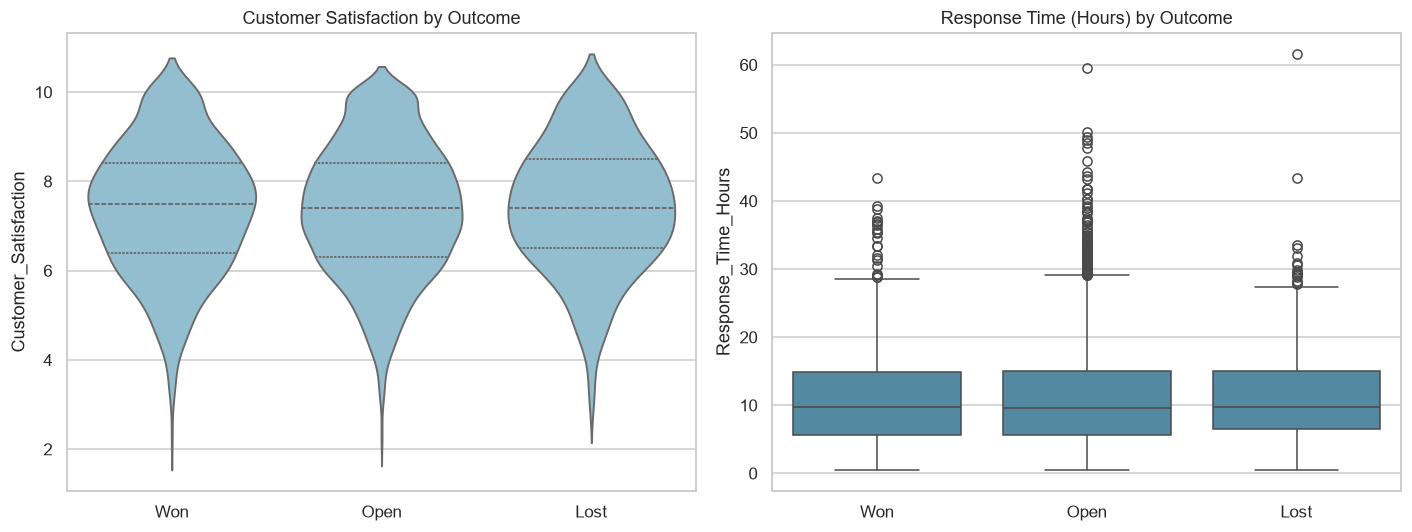

,n,avg_csat,avg_response,avg_lead_score
Outcome,,,,
Won,819,7.39,11.08,78.47
Open,3748,7.36,11.19,56.60
Lost,433,7.43,11.42,46.94


In [9]:
df["Outcome"] = np.where(df["Is_Won"], "Won", np.where(df["Lead_Stage"] == "Lost", "Lost", "Open"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.violinplot(
    data=df.dropna(subset=["Customer_Satisfaction"]),
    x="Outcome",
    y="Customer_Satisfaction",
    order=["Won", "Open", "Lost"],
    ax=axes[0],
    color=COLOR["soft"],
    inner="quartile",
)
axes[0].set_title("Customer Satisfaction by Outcome")
axes[0].set_xlabel("")

sns.boxplot(
    data=df.dropna(subset=["Response_Time_Hours"]),
    x="Outcome",
    y="Response_Time_Hours",
    order=["Won", "Open", "Lost"],
    ax=axes[1],
    color=COLOR["mid"],
)
axes[1].set_title("Response Time (Hours) by Outcome")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

ops = (
    df.groupby("Outcome")
    .agg(
        n=("Customer_ID", "count"),
        avg_csat=("Customer_Satisfaction", "mean"),
        avg_response=("Response_Time_Hours", "mean"),
        avg_lead_score=("Lead_Score", "mean"),
    )
    .reindex(["Won", "Open", "Lost"])
    .round(2)
)
ops

## 8) Insight summary

In [10]:
top_source = source.sort_values("conversion_rate", ascending=False).iloc[0]
top_rep = rep.sort_values("revenue", ascending=False).iloc[0]
top_seg = seg_summary.sort_values("revenue", ascending=False).iloc[0]

from IPython.display import Markdown, display

display(Markdown(f"""
### Dashboard takeaways

| Focus | Finding |
|---|---|
| **Pipeline** | {won:,} won / {total_customers:,} leads (**{conversion:.1%}** conversion); {lost:,} lost |
| **Revenue** | **${total_revenue:,.0f}** total · avg won deal **${avg_won_revenue:,.0f}** |
| **Best source (rate)** | **{top_source['Lead_Source']}** at **{top_source['conversion_rate']:.1%}** ({int(top_source['leads']):,} leads) |
| **Top rep (revenue)** | **{top_rep['Assigned_Sales_Rep']}** · **${top_rep['revenue']:,.0f}** · conversion **{top_rep['conversion_rate']:.1%}** |
| **Top segment** | **{top_seg['Customer_Segment']}** · **${top_seg['revenue']:,.0f}** |
| **Service quality** | Avg CSAT **{avg_csat:.1f}/10** · Avg response **{avg_response:.1f} hrs** · Avg lead score **{avg_lead_score:.0f}** |

**Next actions:** double-down on high-converting sources, coach reps with low conversion but high lead volume, and tighten SLA on slow-response open leads.
"""))


### Dashboard takeaways

| Focus | Finding |
|---|---|
| **Pipeline** | 819 won / 5,000 leads (**16.4%** conversion); 433 lost |
| **Revenue** | **$1,643,197** total · avg won deal **$1,449** |
| **Best source (rate)** | **Website** at **18.5%** (562 leads) |
| **Top rep (revenue)** | **Samer Khalil** · **$329,110** · conversion **17.0%** |
| **Top segment** | **Enterprise** · **$639,056** |
| **Service quality** | Avg CSAT **7.4/10** · Avg response **11.2 hrs** · Avg lead score **59** |

**Next actions:** double-down on high-converting sources, coach reps with low conversion but high lead volume, and tighten SLA on slow-response open leads.


---

## Project complete

| Phase | Artifact |
|---|---|
| 1 Cleaning | `01_CRM_Phase1_Cleaning.ipynb` → `CRM_Cleaned.csv` |
| 2 EDA | `02_CRM_Phase2_EDA.ipynb` |
| 6 Dashboard | `03_CRM_Dashboard.ipynb` (this file) |